In [17]:
import numpy as np
import pandas as pd
import cv2 as cv
import seaborn as sns
from StatTools.generators.ndfnoise_generator import ndfnoise
from StatTools.generators.mfnoise_generator import mfnoise
from StatTools.visualization import plot_ff
from StatTools.analysis.dfa import DFA, dfa, dfa_worker
from StatTools.analysis.utils import(
    analyse_zero_cross_ff,
    analyse_cross_ff_linregress,
    ff_params
) 

from joblib import Parallel, delayed, cpu_count
import plotly.express as px
from tqdm import tqdm
from scipy import stats
import matplotlib.pyplot as plt
from typing import Optional
from pathlib import Path
import os
import pickle as pkl
from collections import defaultdict
# git clone https://github.com/Digiratory/FluctuationAnalysisTools.git
# cd FluctuationAnalysisTools
# mv StatTools/ ../

In [ ]:
# dir_pkl = Path('monte_carlo12')
# level_df12 = defaultdict(list)
# estimated_h = defaultdict(list)
# for file in dir_pkl.iterdir():
#     with open(file, 'rb') as f:
#         df = pkl.load(f)
#         for level in df['results_by_level']:
#             level_df12[level['level']].append(level['F_s'])
#             estimated_h[level['level']].append(level['hurst_estimated'])
# estimated_h_df12 = pd.DataFrame(estimated_h)
# level_df12 = pd.DataFrame(level_df12)
# estimated_h_df12.to_pickle('estimated_h_12.pkl')
# level_df12.to_pickle('level_df12.pkl')


In [ ]:
# dir_pkl = Path('monte_carlo08')
# level_df08 = defaultdict(list)
# estimated_h = defaultdict(list)
# for file in dir_pkl.iterdir():
#     with open(file, 'rb') as f:
#         df = pkl.load(f)
#         for level in df['results_by_level']:
#             level_df08[level['level']].append(level['F_s'])
#             estimated_h[level['level']].append(level['hurst_estimated'])
# estimated_h_df08 = pd.DataFrame(estimated_h)
# level_df08 = pd.DataFrame(level_df08)
# estimated_h_df08.to_pickle('estimated_h_08.pkl')
# level_df08.to_pickle('level_df08.pkl')

In [20]:
estimated_h_df08 = pd.read_pickle('estimated_h_08.pkl')
estimated_h_df12 = pd.read_pickle('estimated_h_12.pkl')

level_df08 = pd.read_pickle('level_df08.pkl')
level_df12 = pd.read_pickle('level_df12.pkl')

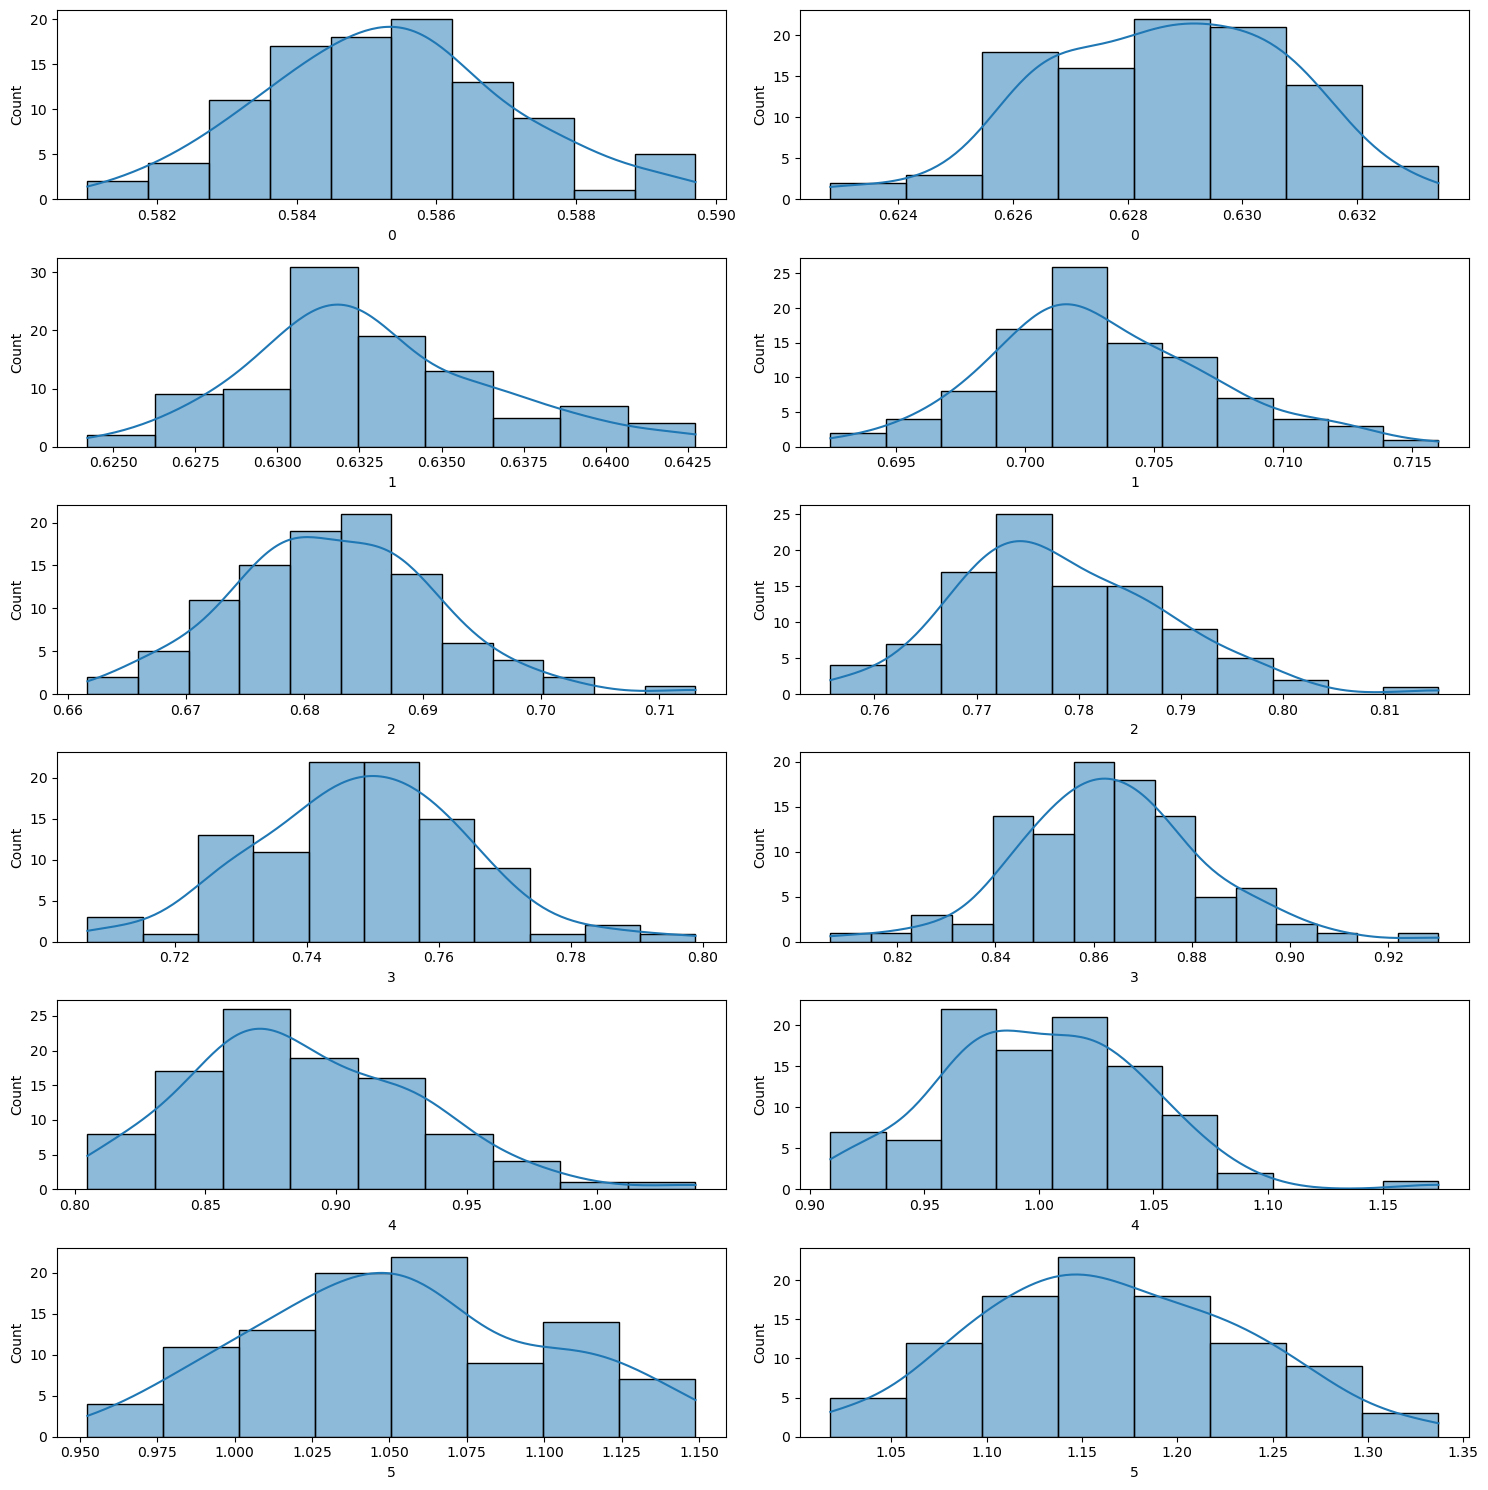

,0,1,2,3,4,5
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.585305,0.632847,0.682493,0.748482,0.887537,1.053454
std,0.001779,0.003752,0.008760,0.016282,0.043931,0.046722
min,0.581006,0.624213,0.661673,0.706738,0.804934,0.952509
25%,0.584058,0.630542,0.677125,0.738112,0.856737,1.018061
50%,0.585289,0.632344,0.682109,0.748970,0.880505,1.054127
75%,0.586280,0.635380,0.687689,0.758534,0.920495,1.084794
max,0.589707,0.642736,0.713060,0.798927,1.037547,1.148840


,0,1,2,3,4,5
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.628625,0.703022,0.778307,0.863812,1.001002,1.164830
std,0.002119,0.004401,0.010283,0.019286,0.044792,0.069491
min,0.622823,0.692465,0.755690,0.806378,0.909007,1.017995
25%,0.626922,0.700545,0.771561,0.853888,0.971588,1.118474
50%,0.628645,0.702241,0.776869,0.863247,0.997757,1.157709
75%,0.630228,0.705618,0.784480,0.874382,1.032532,1.214868
max,0.633413,0.716040,0.815233,0.930245,1.174354,1.336938


In [ ]:
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 15), sharex=False)
# axes = np.atleast_2d(axes).flatten()
for level, ax in enumerate(axes):
    sns.histplot(estimated_h_df08[level], kde=True, element='bars', ax=ax[0])
    sns.histplot(estimated_h_df12[level], kde=True, element='bars', ax=ax[1])
    
plt.show()
display(estimated_h_df08.describe())
display(estimated_h_df12.describe())

In [22]:
s_values = np.array([int(np.exp(step)) for step in np.arange(np.log(6), np.log(2048/4), 0.5)])

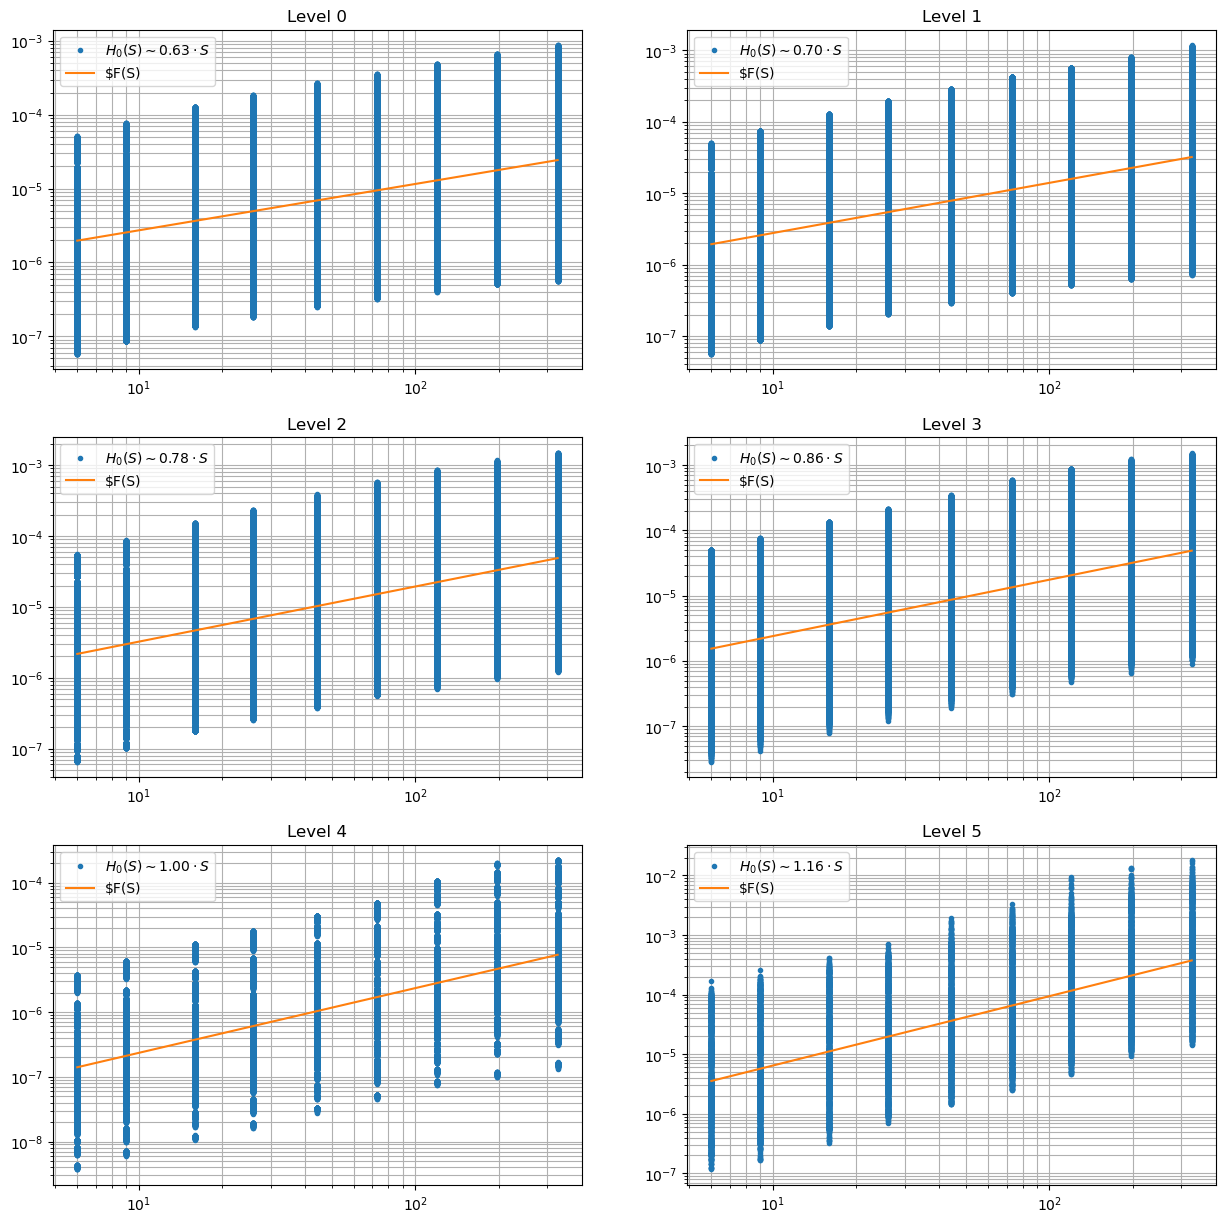

In [23]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = np.atleast_2d(axes).flatten()
for level, ax in enumerate(axes):

    data_lvl = np.concat(level_df12[level])
    ff_parameters, _ = analyse_zero_cross_ff(data_lvl, s_values)

    plot_ff(
        data_lvl,
        s_values,
        ff_parameter=ff_parameters,
        residuals=None,
        ax=ax,
        title=f'Level {level}'
    )

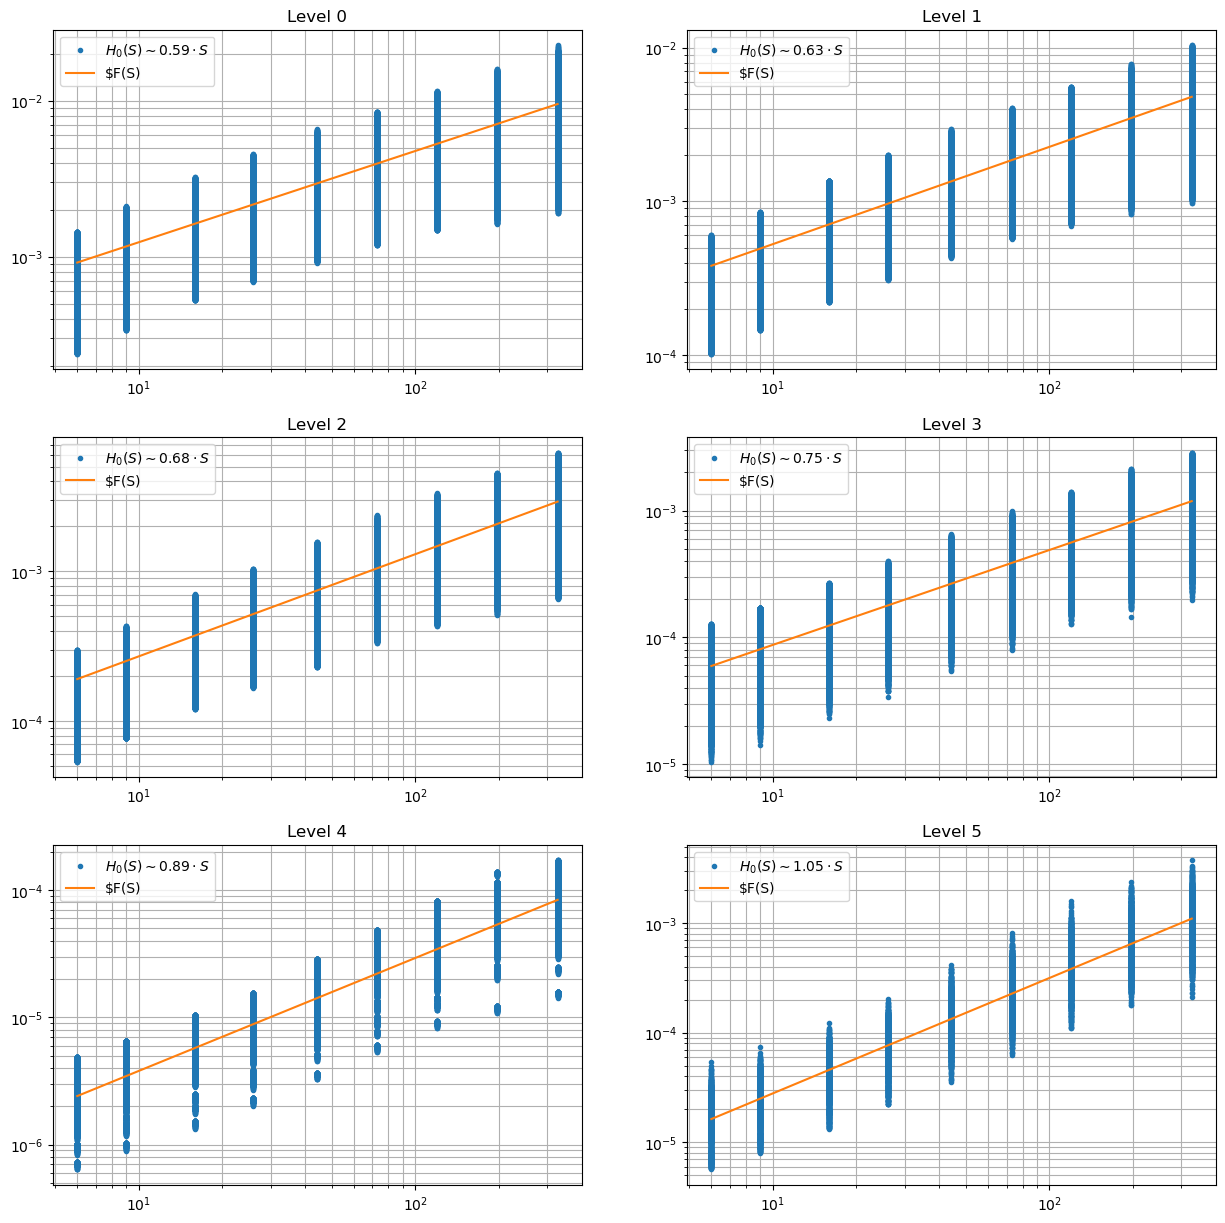

In [24]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = np.atleast_2d(axes).flatten()
for level, ax in enumerate(axes):

    data_lvl = np.concat(level_df08[level])
    ff_parameters, _ = analyse_zero_cross_ff(data_lvl, s_values)

    plot_ff(
        data_lvl,
        s_values,
        ff_parameter=ff_parameters,
        residuals=None,
        ax=ax,
        title=f'Level {level}'
    )

In [25]:
# plt.violinplot(np.concat(level_dfs12[0]), positions=s_values, widths = s_values/3)
# plt.xscale('log')
# plt.yscale('log')
# plt.grid('both', 'both')
# plt.show()